# PyTorch Basics: Teaching a Neural Network to Add

## IMPRS Lecture Week 2026

---

In this short tutorial we will build and train a simple neural network in [PyTorch](https://pytorch.org) that learns to perform **addition** of two numbers. While addition is of course trivial analytically, it's a useful toy problem because:

- It exposes all the core ingredients of a PyTorch training loop (dataset, model, loss, optimizer, backprop).
- The ground truth is known, so we can easily check whether the network has learned.
- It runs in seconds on a laptop.

### Steps

1. **Generate a training set** of $(a, b, a+b)$ triples.
2. **Package the data** into a PyTorch `Dataset` and `DataLoader`.
3. **Define a small MLP** by subclassing `nn.Module`.
4. **Train** the network using mean-squared error and the Adam optimizer.
5. **Evaluate** on unseen inputs.

### Exercises

1. Replace addition with multiplication. Does a small MLP still work?
2. Change the activation function (e.g. `nn.Tanh`, `nn.GELU`). How does it affect training?
3. Train on inputs in $[-1, 1]$ but evaluate on $[-10, 10]$. Does the network extrapolate?

## Imports

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

In [13]:
# If running on Apple Silicon or CUDA is available, use the GPU.

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: cpu


## What is pytorch

To first approximation, pytorch is an optimized numpy library that has **autograd**. 

**autograd** means PyTorch silently records every operation performed on a tensor that has `requires_grad=True`, building a computation graph on the fly. A single call to `.backward()` on a scalar output then walks that graph in reverse and fills in the gradient of the output with respect to every input tensor. This is basically repeated application of the chain rule. 

As a quick sanity check, let's compute the derivative of $z = x^3+ x$ at $x = 2$. Analytically, $\frac{dz}{dx} = 3 x^2 + 1 = 13$.


In [14]:
# A torch.Tensor looks and behaves a lot like a numpy array.
# This one has requires_grad=True. Any Tensor that touches x becomes "infected"
# with gradient tracking.
x = torch.tensor(2.0, requires_grad=True)

# Forward pass builds this graph (x feeds z through TWO paths):
#
#                   y = x**3                 z = y + x
#             x  ──────────▶  y  ───────────────▶  z
#             │                                     ▲
#             └─────────  x feeds z directly  ──────┘
#
y = x**3      # y = 8.   PowBackward stores local derivative   dy/dx = 3*x**2
z = y + x     # z = 10.  AddBackward stores local derivatives  dz/dy = 1, dz/dx = 1

# The forward pass populated the computation graph. Each tensor produced by an
# op carries a grad_fn -- the backward "recipe" for that op. next_functions
# tells us which grad_fns feed into it, i.e. how to walk the graph in reverse.
print(f"z.grad_fn                = {z.grad_fn}")
print(f"z.grad_fn.next_functions = {z.grad_fn.next_functions}") # AccumulateGrad refers to the final leaf (+x in this case)
print(f"y.grad_fn                = {y.grad_fn}")
print(f"x.grad_fn                = {x.grad_fn}")

z.grad_fn                = <AddBackward0 object at 0x7f9d29c1c190>
z.grad_fn.next_functions = ((<PowBackward0 object at 0x7f9d29aa32b0>, 0), (<AccumulateGrad object at 0x7f9d299d8df0>, 0))
y.grad_fn                = <PowBackward0 object at 0x7f9d3162fd30>
x.grad_fn                = None


In [15]:
# Now we can take the derivative. Note we never wrote down the symbolic
# derivative of z! We just recorded local derivatives during the forward pass,
# and backward() assembles dz/dx from them using the chain rule:
#
#   path via y   (x -> y -> z):   (dz/dy) * (dy/dx)  =  1 * 3*x**2  =  12
#   path direct  (x ->      z):    dz/dx              =  1
#   ------------------------------------------------------------------
#   total  dz/dx  (autograd sums contributions over all paths)     =  13
z.backward()   # read as: "differentiate z with respect to every leaf that led to it"
print("z               =", z.item())

print("dz/dx (autograd)=", x.grad.item(), "(analytic: 3*x**2 + 1 = 13.0)")

# y is an intermediate (non-leaf), so autograd discards its gradient by default.
# If you wanted to keep it, you'd call y.retain_grad() before backward().

# Note this is forward mode autodiff, see https://math.stackexchange.com/questions/2195377/reverse-mode-differentiation-vs-forward-mode-differentiation-where-are-the-be 
# for the difference compared to backward mode autodiff

z               = 10.0
dz/dx (autograd)= 13.0 (analytic: 3*x**2 + 1 = 13.0)


**What happens if we redo the cell above?**

In [ ]:
# Is this more computationally efficient compared to symbolic differentiation? Why?

# Why autodiff beats symbolic differentiation on deep compositions:
#
# Take f(x) = sin(sin(sin(sin(x)))). Symbolic differentiation gives:
#   f'(x) = cos(sin(sin(sin(x)))) * cos(sin(sin(x))) * cos(sin(x)) * cos(x)
# Evaluating this formula requires 3+2+1+0 = 6 sin calls + 4 cos calls = 10 trig ops.
# At depth n, this scales as O(n^2) because nested sins are recomputed each time.
#
# Autodiff caches intermediates in a forward pass, then reuses them in the backward pass:
#   Forward:  u1=sin(x), u2=sin(u1), u3=sin(u2), u4=sin(u3)     # 4 sin calls
#   Backward: multiply by cos(u3), cos(u2), cos(u1), cos(x)     # 4 cos calls
# Total: 8 trig ops, scaling as O(n).
#
# Symbolic formulas have no memory of intermediate values — each nested subexpression
# is recomputed on evaluation. Autodiff operates on the computational graph and
# reuses cached values, which is why reverse-mode AD computes gradients in time
# proportional to evaluating f itself (the "cheap gradient principle").

## Regression: learning addition

Now we put the pieces together. We build a tiny MLP that takes two numbers $(a, b)$ and learns to output their sum $a+b$, trained by gradient descent on mean-squared error.

In [16]:
# 1. Prepare training data
# Sample pairs (a, b) uniformly from [-1, 1] and label them with a + b.
# We wrap the tensors in a TensorDataset and split into train/val DataLoaders.

from torch.utils.data import TensorDataset

torch.manual_seed(0)

N = 8_000
X = torch.empty(N, 2).uniform_(-1.0, 1.0)      # inputs:  (a, b)
y = X.sum(dim=1, keepdim=True)                 # targets: a + b, shape (N, 1)

dataset = TensorDataset(X, y)
n_train = int(0.9 * N)
train_set, val_set = random_split(dataset, [n_train, N - n_train])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

print(f"Train: {len(train_set)}   Val: {len(val_set)}")
print(f"Example (a, b) -> a+b:  {X[0].tolist()}  ->  {y[0].item():.3f}")


Train: 7200   Val: 800
Example (a, b) -> a+b:  [-0.007486820220947266, 0.5364435911178589]  ->  0.529


epoch  0  train MSE = 4.48e-01   val MSE = 2.13e-01
epoch  2  train MSE = 3.86e-03   val MSE = 1.55e-03
epoch  4  train MSE = 7.12e-04   val MSE = 5.88e-04
epoch  6  train MSE = 4.11e-04   val MSE = 3.62e-04
epoch  8  train MSE = 2.67e-04   val MSE = 2.44e-04
epoch 10  train MSE = 1.73e-04   val MSE = 1.54e-04
epoch 12  train MSE = 1.16e-04   val MSE = 1.04e-04
epoch 14  train MSE = 8.51e-05   val MSE = 7.69e-05
epoch 16  train MSE = 6.90e-05   val MSE = 6.22e-05
epoch 18  train MSE = 5.85e-05   val MSE = 5.35e-05
epoch 19  train MSE = 5.40e-05   val MSE = 5.01e-05


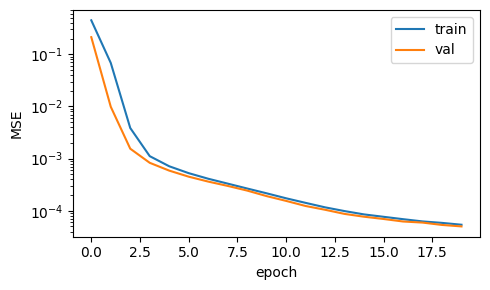

In [17]:
# 2. Define and train the network
# A small MLP: 2 -> 32 -> 32 -> 1, ReLU activations. We minimise MSE with Adam.

class AdderMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

model = AdderMLP().to(device)
# Adam basically does some mathematical tricks to reach the loss faster
# computes adaptive learning rates for each parameter
# https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 20
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    # -- train --
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()           # autograd fills .grad on every parameter
        optimizer.step()          # Adam update

        running += loss.item() * xb.size(0)
    train_hist.append(running / len(train_set))

    # -- validate --
    model.eval()
    with torch.no_grad():
        running = 0.0
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            running += loss_fn(model(xb), yb).item() * xb.size(0)
    val_hist.append(running / len(val_set))

    if epoch % 2 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:2d}  train MSE = {train_hist[-1]:.2e}   val MSE = {val_hist[-1]:.2e}")

plt.figure(figsize=(5, 3))
plt.semilogy(train_hist, label="train")
plt.semilogy(val_hist,   label="val")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.tight_layout()
plt.show()


  +0.10 + +0.20  ->  pred +0.2846   (true +0.3000)
  -0.50 + +0.30  ->  pred -0.1961   (true -0.2000)
  +0.90 + -0.70  ->  pred +0.1918   (true +0.2000)
  +0.00 + +0.00  ->  pred -0.0162   (true +0.0000)


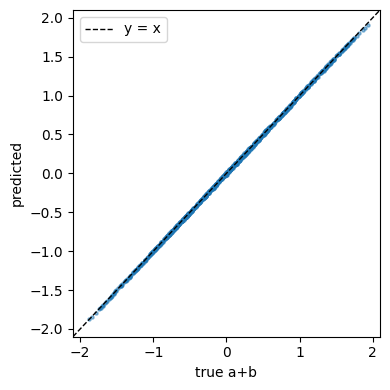

In [18]:
# 3. Evaluate on a handful of new inputs and plot predicted vs. true.

model.eval()
with torch.no_grad():
    probe = torch.tensor([[0.1, 0.2], [-0.5, 0.3], [0.9, -0.7], [0.0, 0.0]])
    pred = model(probe.to(device)).cpu().squeeze(1)
    for (a, b), p in zip(probe.tolist(), pred.tolist()):
        print(f"  {a:+.2f} + {b:+.2f}  ->  pred {p:+.4f}   (true {a + b:+.4f})")

    # Scatter of predicted vs true over a fresh sample.
    X_test = torch.empty(1000, 2).uniform_(-1.0, 1.0)
    y_test = X_test.sum(dim=1, keepdim=True)
    y_pred = model(X_test.to(device)).cpu()

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, s=5, alpha=0.5)
lims = [-2.1, 2.1]
plt.plot(lims, lims, "k--", lw=1, label="y = x")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("true a+b"); plt.ylabel("predicted")
plt.legend(); plt.tight_layout()
plt.show()
